<a href="https://colab.research.google.com/github/shamitha067/shamitha_codebooster_2026/blob/main/Day10/Day10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("student_performance.csv")
df.head()
print("The Dataset successfully loaded")

The Dataset successfully loaded


In [ ]:
import sqlite3

# Establish connection to the database
conn = sqlite3.connect('internship.db')

# Write the DataFrame 'df' to a SQL table named 'students'
# If the table already exists, it will be replaced.
df.to_sql('students', conn, if_exists='replace', index=False)

# SQL query to fetch data from the 'students' table
query = "SELECT * FROM students LIMIT 5"

# Fetch data into a pandas DataFrame
result = pd.read_sql(query, conn)
print(result)

# Close the database connection
conn.close()

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

In [ ]:
import sqlite3


In [ ]:
import sqlite3

conn = sqlite3.connect('internship.db')

df.to_sql('students', conn, if_exists='replace', index=False)

conn.commit()

sql_query = "SELECT student_id, name, department, math_score FROM students"
sql_result_df = pd.read_sql_query(sql_query, conn)
display(sql_result_df.head())

# Close the database connection
conn.close()

,student_id,name,department,math_score
0,1001,Aarav Sharma,Computer Science,85
1,1002,Priya Patel,Computer Science,76
2,1003,Rohit Verma,Electronics,65
3,1004,Sneha Reddy,Mechanical,70
4,1005,Arjun Nair,Computer Science,92


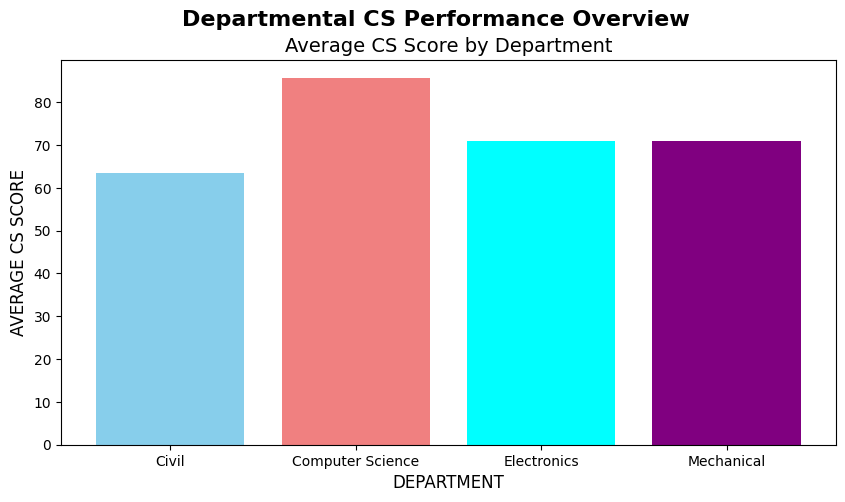

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
#colors = ['skyblue', 'lightcoral', 'cyan', 'purple']

# Calculate average math score per department
data = df.groupby('department')['math_score'].mean().reset_index()
data = data.rename(columns={'math_score': 'avg_math'})

plt.suptitle("Departmental CS Performance Overview", fontsize=16, fontweight='bold') # Overall title
plt.xlabel("DEPARTMENT", fontsize=12)
plt.ylabel("AVERAGE CS SCORE", fontsize=12)
plt.title("Average CS Score by Department", fontsize=14)
ax.bar(data['department'], data['avg_math'], color=colors)
plt.show()

In [ ]:
import pandas as pd

# EXTRACT
df = pd.read_csv("student_performance.csv")

# TRANSFORM
df = df.drop_duplicates()      # Remove duplicates
df = df.fillna(0)             # Replace missing values with 0

# LOAD
df.to_csv("cleaned_student_performance.csv", index=False)

print("ETL Process Completed Successfully!")

ETL Process Completed Successfully!


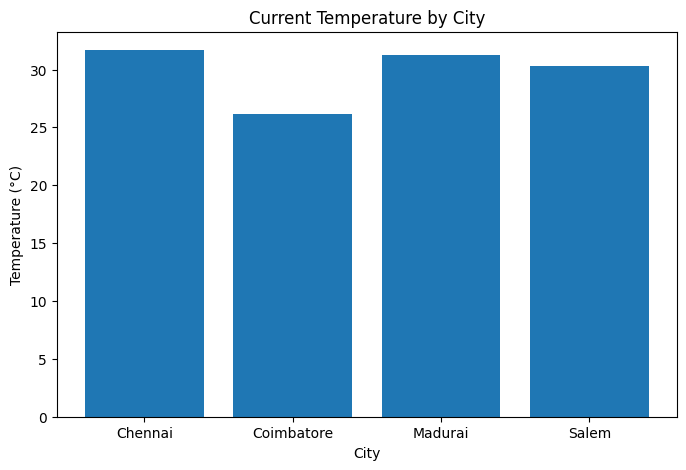

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

API_KEY = "33499632c1a18060c1259394749d19ef"

cities = ["Chennai", "Coimbatore", "Madurai", "Salem"]
temperatures = []

for city in cities:
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"
    response = requests.get(url)
    data = response.json()

    temperatures.append(data["main"]["temp"])

df = pd.DataFrame({
    "City": cities,
    "Temperature": temperatures
})

plt.figure(figsize=(8,5))
plt.bar(df["City"], df["Temperature"])
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.title("Current Temperature by City")
plt.show()

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when

spark = SparkSession.builder \
    .appName("StudentAnalysis") \
    .getOrCreate()

data = [
    (1, "Ravi", 95),
    (2, "Priya", 82),
    (3, "Arun", 68),
    (4, "Divya", 55),
    (5, "Kumar", 40)
]

columns = ["student_id", "student_name", "math_score"]


df = spark.createDataFrame(data, columns)


df_transformed = df.withColumn(
    "performance",
    when(df.math_score >= 90, "Excellent")
    .when(df.math_score >= 75, "Good")
    .when(df.math_score >= 50, "Average")
    .otherwise("Needs Improvement")
)

df_transformed.show()

+----------+------------+----------+-----------------+
|student_id|student_name|math_score|      performance|
+----------+------------+----------+-----------------+
|         1|        Ravi|        95|        Excellent|
|         2|       Priya|        82|             Good|
|         3|        Arun|        68|          Average|
|         4|       Divya|        55|          Average|
|         5|       Kumar|        40|Needs Improvement|
+----------+------------+----------+-----------------+



In [3]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

spark = SparkSession.builder.appName("StudentPrediction").getOrCreate()


data = [
    (1, 70, 75),
    (2, 80, 85),
    (3, 90, 95),
    (4, 60, 65),
    (5, 85, 88)
]

columns = ["student_id", "math_score", "final_score"]

df = spark.createDataFrame(data, columns)


assembler = VectorAssembler(
    inputCols=["math_score"],
    outputCol="features"
)

df_features = assembler.transform(df)

lr = LinearRegression(
    featuresCol="features",
    labelCol="final_score"
)

model = lr.fit(df_features)


new_data = spark.createDataFrame(
    [(95,)],
    ["math_score"]
)

new_features = assembler.transform(new_data)
prediction = model.transform(new_features)

predicted_score = prediction.collect()[0]["prediction"]

if predicted_score >= 90:
    message = f"The student is predicted to score {predicted_score:.2f}. Performance is Excellent."
elif predicted_score >= 75:
    message = f"The student is predicted to score {predicted_score:.2f}. Performance is Good."
else:
    message = f"The student is predicted to score {predicted_score:.2f}. Performance needs improvement."

print(message)

The student is predicted to score 99.10. Performance is Excellent.
